# Visualizing the Learned Weights

This notebook visualizes the learned weights of the K-Means Transformer model, comparing them with the theoretical handcrafted weights from Theorem 2.1.

## Setup and Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

# Set print options
np.set_printoptions(precision=2)
torch.set_printoptions(precision=2)

# Import project modules
from kmt import KModel

print(f"Cuda available: {torch.cuda.is_available()}")
GPUE = torch.cuda.is_available()

Cuda available: True


## Helper Functions

In [2]:
def wmat(demb, start, end, sign=1):
    """Create a weight matrix with identity block from start to end."""
    assert 0 <= start < demb
    assert 0 < end <= demb
    assert start < end
    ret = torch.zeros((demb, demb))
    idxs = torch.arange(start, end)
    ret[idxs, idxs] = 1
    return torch.nn.Parameter(sign * ret)

In [3]:
def handcrafted_model(m, demb, NDIMS):
    """Set up handcrafted model weights according to Theorem 2.1."""
    # Cross-attention X (CAX)
    m.CAX.W_q.weight = wmat(demb, 0, NDIMS)
    m.CAX.W_k.weight = wmat(demb, 0, NDIMS)
    m.CAX.W_v.weight = wmat(demb, NDIMS, demb)
    
    # Self-attention X (SAX)
    m.SAX.W_q.weight = wmat(demb, 0, NDIMS)
    m.SAX.W_k.weight = wmat(demb, 0, NDIMS)
    m.SAX.W_v.weight = wmat(demb, NDIMS, demb, sign=-1)
    
    # Cross-attention C (CAC)
    m.CAC.W_q.weight = wmat(demb, NDIMS, demb)
    m.CAC.W_k.weight = wmat(demb, NDIMS, demb)
    m.CAC.W_v.weight = wmat(demb, 0, NDIMS)
    
    # Self-attention C (SAC)
    m.SAC.W_q.weight = wmat(demb, NDIMS, demb)
    m.SAC.W_k.weight = wmat(demb, NDIMS, demb)
    m.SAC.W_v.weight = wmat(demb, 0, NDIMS, sign=-1)
    
    # Zero out all biases
    for module in [m.CAX, m.SAX, m.CAC, m.SAC]:
        module.W_q.bias = torch.nn.Parameter(torch.zeros_like(module.W_q.bias))
        module.W_k.bias = torch.nn.Parameter(torch.zeros_like(module.W_k.bias))
        module.W_v.bias = torch.nn.Parameter(torch.zeros_like(module.W_v.bias))
    
    return m

In [4]:
def varname(name):
    """Convert parameter name to LaTeX label."""
    module = name.replace('.weight', '')
    mdict = {
        'CAX.W_q': r'$Q_1$',
        'CAX.W_k': r'$K_1$',
        'CAX.W_v': r'$V_1$',
        'SAX.W_q': r'$Q_2$',
        'SAX.W_k': r'$K_2$',
        'SAX.W_v': r'$V_2$',
        'CAC.W_q': r'$Q_3$',
        'CAC.W_k': r'$K_3$',
        'CAC.W_v': r'$V_3$',
        'SAC.W_q': r'$Q_4$',
        'SAC.W_k': r'$K_4$',
        'SAC.W_v': r'$V_4$',
    }
    return mdict[module]

In [5]:
def plot_weights(m, axs, prefix, nrows, cmap='inferno_r'):
    """Plot weight matrices for the model."""
    idx = 0
    Q, K = None, None
    nq, nk = None, None
    
    for n, p in m.named_parameters():
        if 'weight' not in n:
            continue
        
        nn = varname(n)
        if 'W_q' in n:
            assert Q is None
            Q, nq = p, nn
        if 'W_k' in n:
            assert K is None
            K, nk = p, nn
        
        ridx = idx // nrows
        cidx = idx - (ridx * nrows)
        ax = axs[ridx, cidx]
        ax.set_aspect('equal')
        ax.set_title(prefix + ' ' + nn)
        im = ax.imshow(p.detach().numpy(), cmap=cmap)
        cbar = ax.figure.colorbar(im, ax=ax)
        
        idx += 1
        if cidx == 2:
            assert Q is not None
            assert K is not None
            W = Q.T @ K
            ax = axs[ridx, cidx+1]
            ax.set_aspect('equal')
            ax.set_title(prefix + ' ' + nq + r'$\!\!{}^\top\!\!$' + nk)
            im = ax.imshow(W.detach().numpy(), cmap=cmap)
            cbar = ax.figure.colorbar(im, ax=ax)
            Q, K = None, None
            idx += 1
    
    return idx

## Load Model Checkpoint

In [6]:
# Specify checkpoint path
CHKPT = "runs/n=512_N=512_k=10_d=32_D=normal_s=0.1_em=True_es=True_sdb=True_e=onehot_q=1_A=softmax_a=1.0_p=0.01_L=softmax_g=False_l=10.0_E=153476998_b=32_r=0.01_C=0.5_P=5.0_T=10000_t=50_B=10_last.pt"

assert os.path.exists(CHKPT), f"Checkpoint not found: {CHKPT}"

# Load checkpoint
checkpoint = torch.load(CHKPT)
NDIMS = checkpoint['cli_args']['ndims']
K = checkpoint['cli_args']['nclusters']
SEED = checkpoint['cli_args']['seed']

# Set random seeds
RNG = np.random.RandomState(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Model trained for d={NDIMS}, k={K}")
print(f"Seed: {SEED}")

cli_args = checkpoint['cli_args']
demb = NDIMS + K
print(f"Embedding dimension: {demb}")

Model trained for d=32, k=10
Seed: 153476998
Embedding dimension: 42


## Visualize Weight Matrices

Compare the theoretical handcrafted weights (Theorem 2.1) with the learned weights.

Plotting handcrafted weights (Theorem 2.1)...
Plotting learned weights...


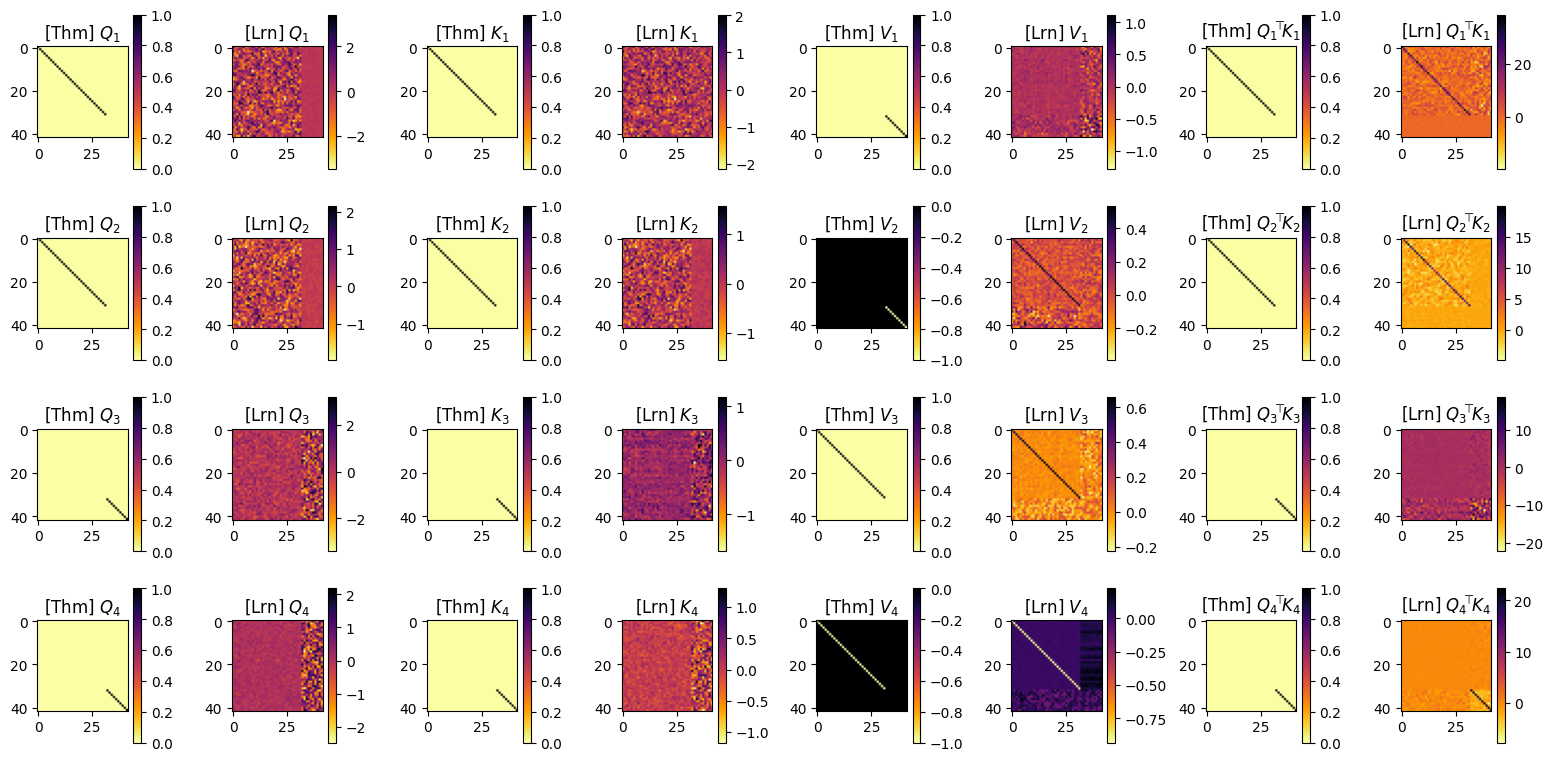

In [7]:
# Setup figure
nrows, ncols = 4, 4
mult = 1.95
fig, axs = plt.subplots(nrows, 2*ncols, figsize=(2*ncols*mult, nrows*mult))
CMAP = 'inferno_r'

# Create handcrafted model (Theorem 2.1)
model_theory = KModel(
    demb, cli_args['dqkv']*demb,
    inv_temp=1000,  # Large gamma for hard attention
    dropout_p=cli_args['dropout'],
    act=cli_args['attn_act'],
)
model_theory = handcrafted_model(model_theory, demb, NDIMS)
model_theory.eval()

# Plot handcrafted weights
print("Plotting handcrafted weights (Theorem 2.1)...")
plot_weights(model_theory, axs[:, 2*np.arange(ncols)], '[Thm]', nrows, CMAP)

# Load trained model
model_learned = KModel(
    demb, cli_args['dqkv']*demb,
    inv_temp=cli_args['attn_itemp'],
    dropout_p=cli_args['dropout'],
    act=cli_args['attn_act'],
)
model_learned.load_state_dict(checkpoint['model_state_dict'])
model_learned.eval()

# Plot learned weights
print("Plotting learned weights...")
plot_weights(model_learned, axs[:, 2*np.arange(ncols)+1], '[Lrn]', nrows, CMAP)

fig.tight_layout()
plt.show()

In [8]:
# Save figure
ODIR = "results/"
assert os.path.isdir(ODIR)
OFILE = os.path.join(ODIR, f'weights_d{NDIMS}_k{K}.pdf')
fig.savefig(OFILE, bbox_inches='tight')
print(f"Saved to {OFILE}")

Saved to results/weights_d32_k10.pdf
